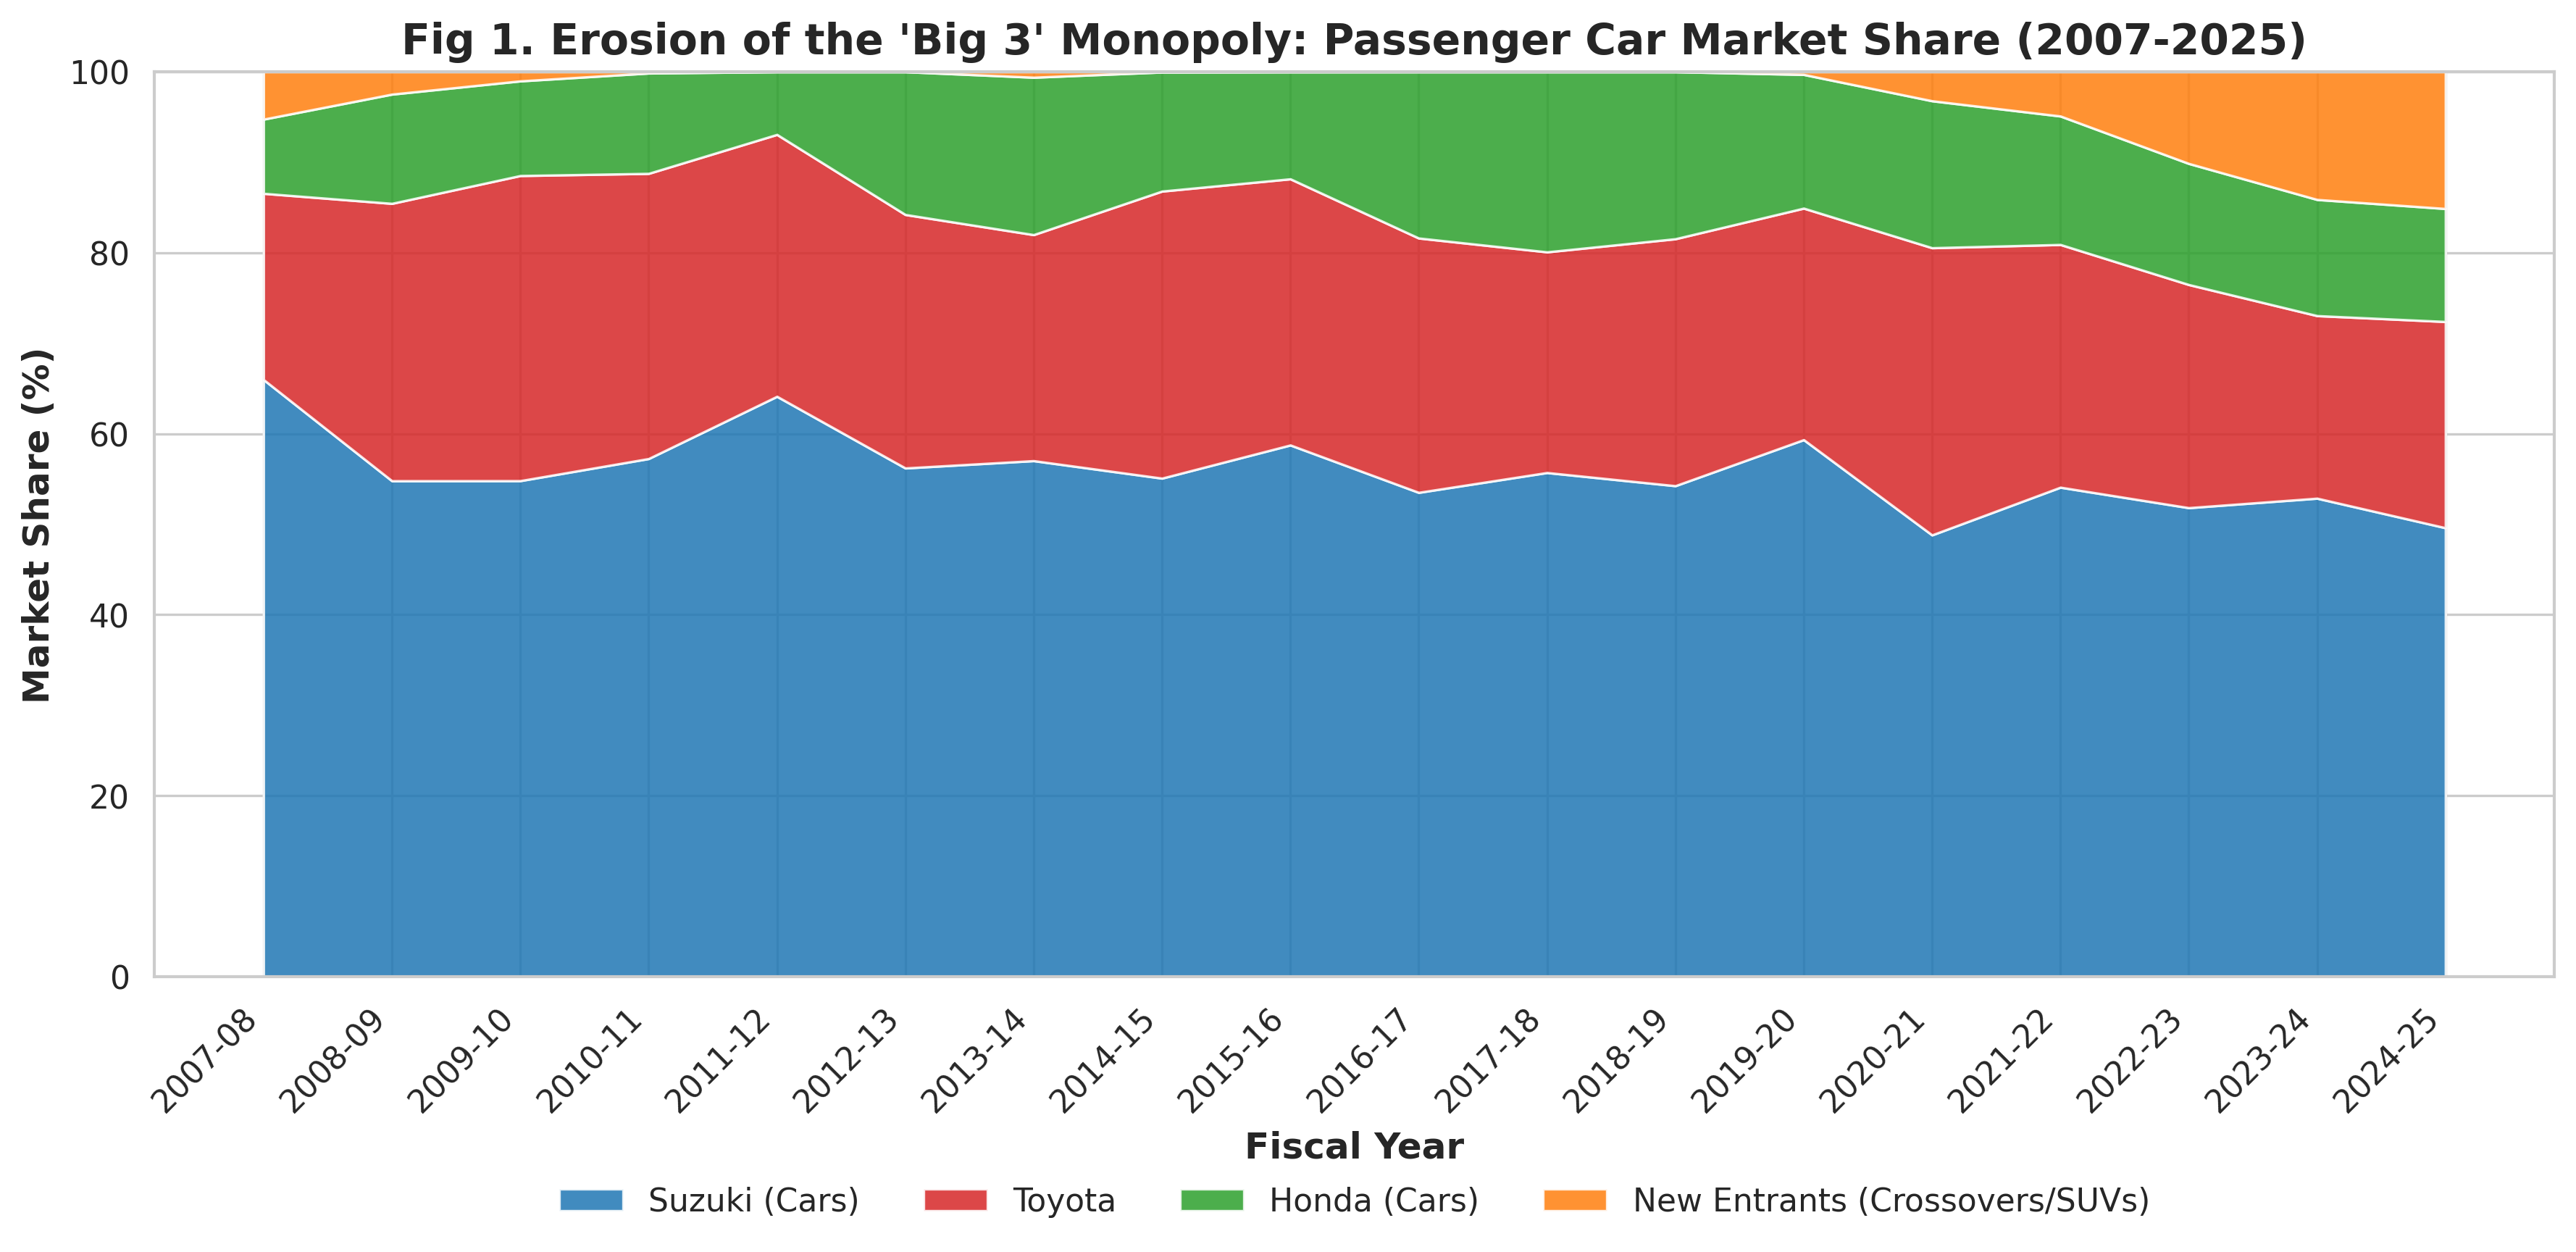

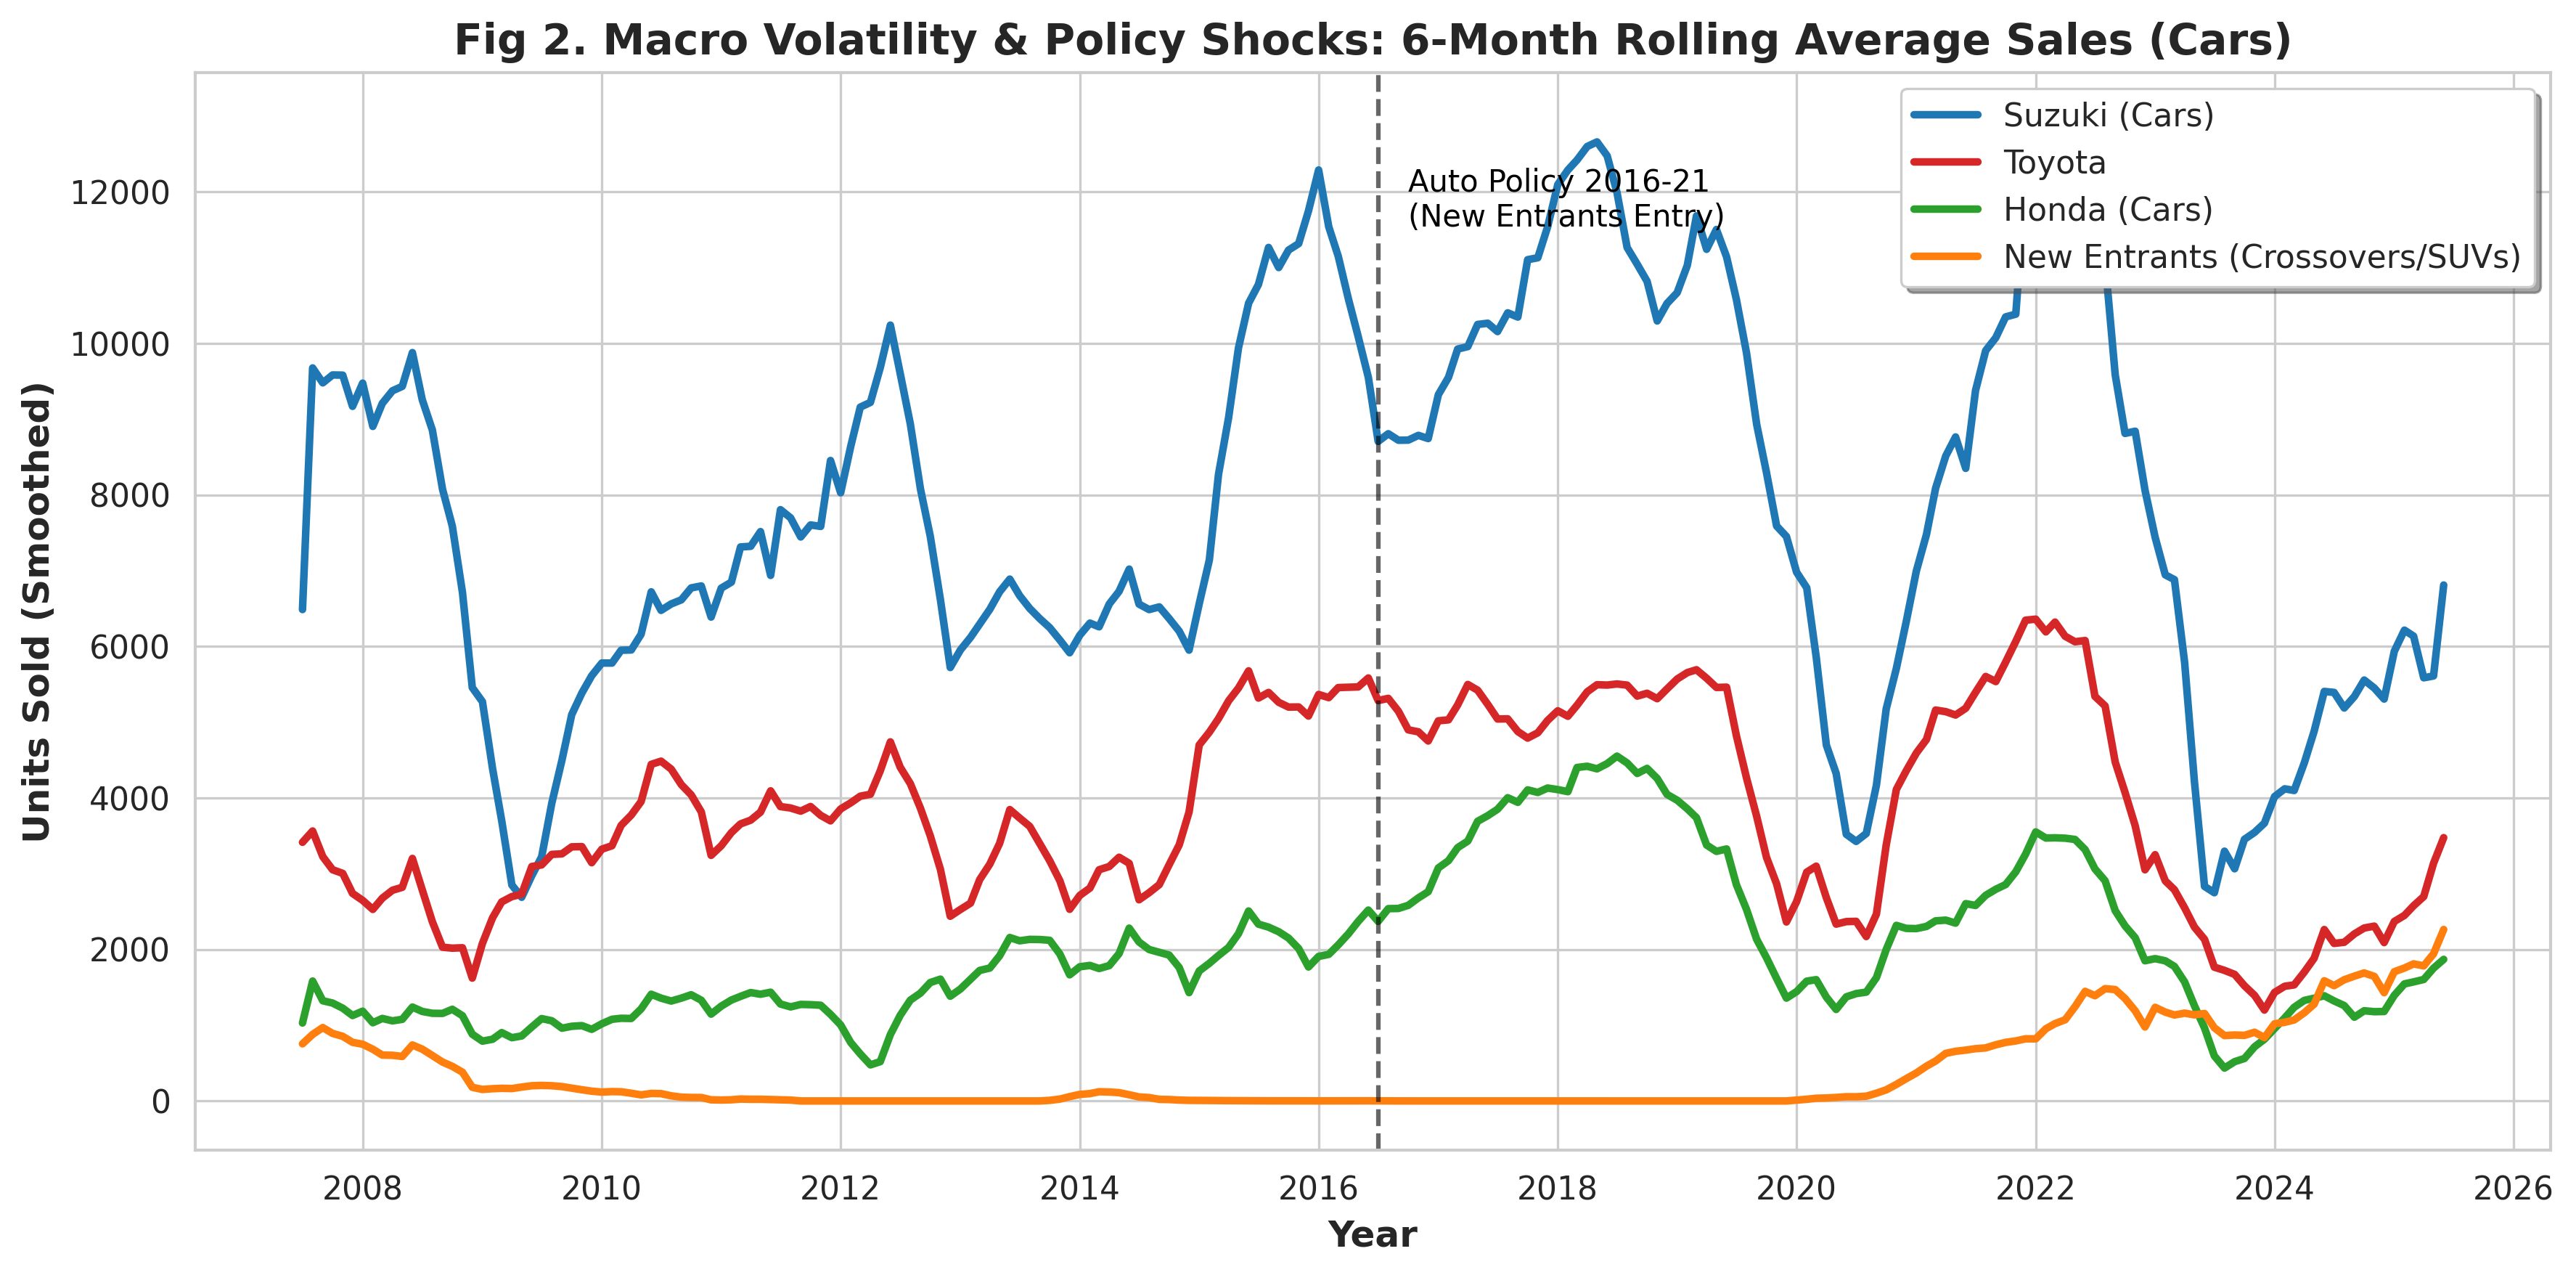

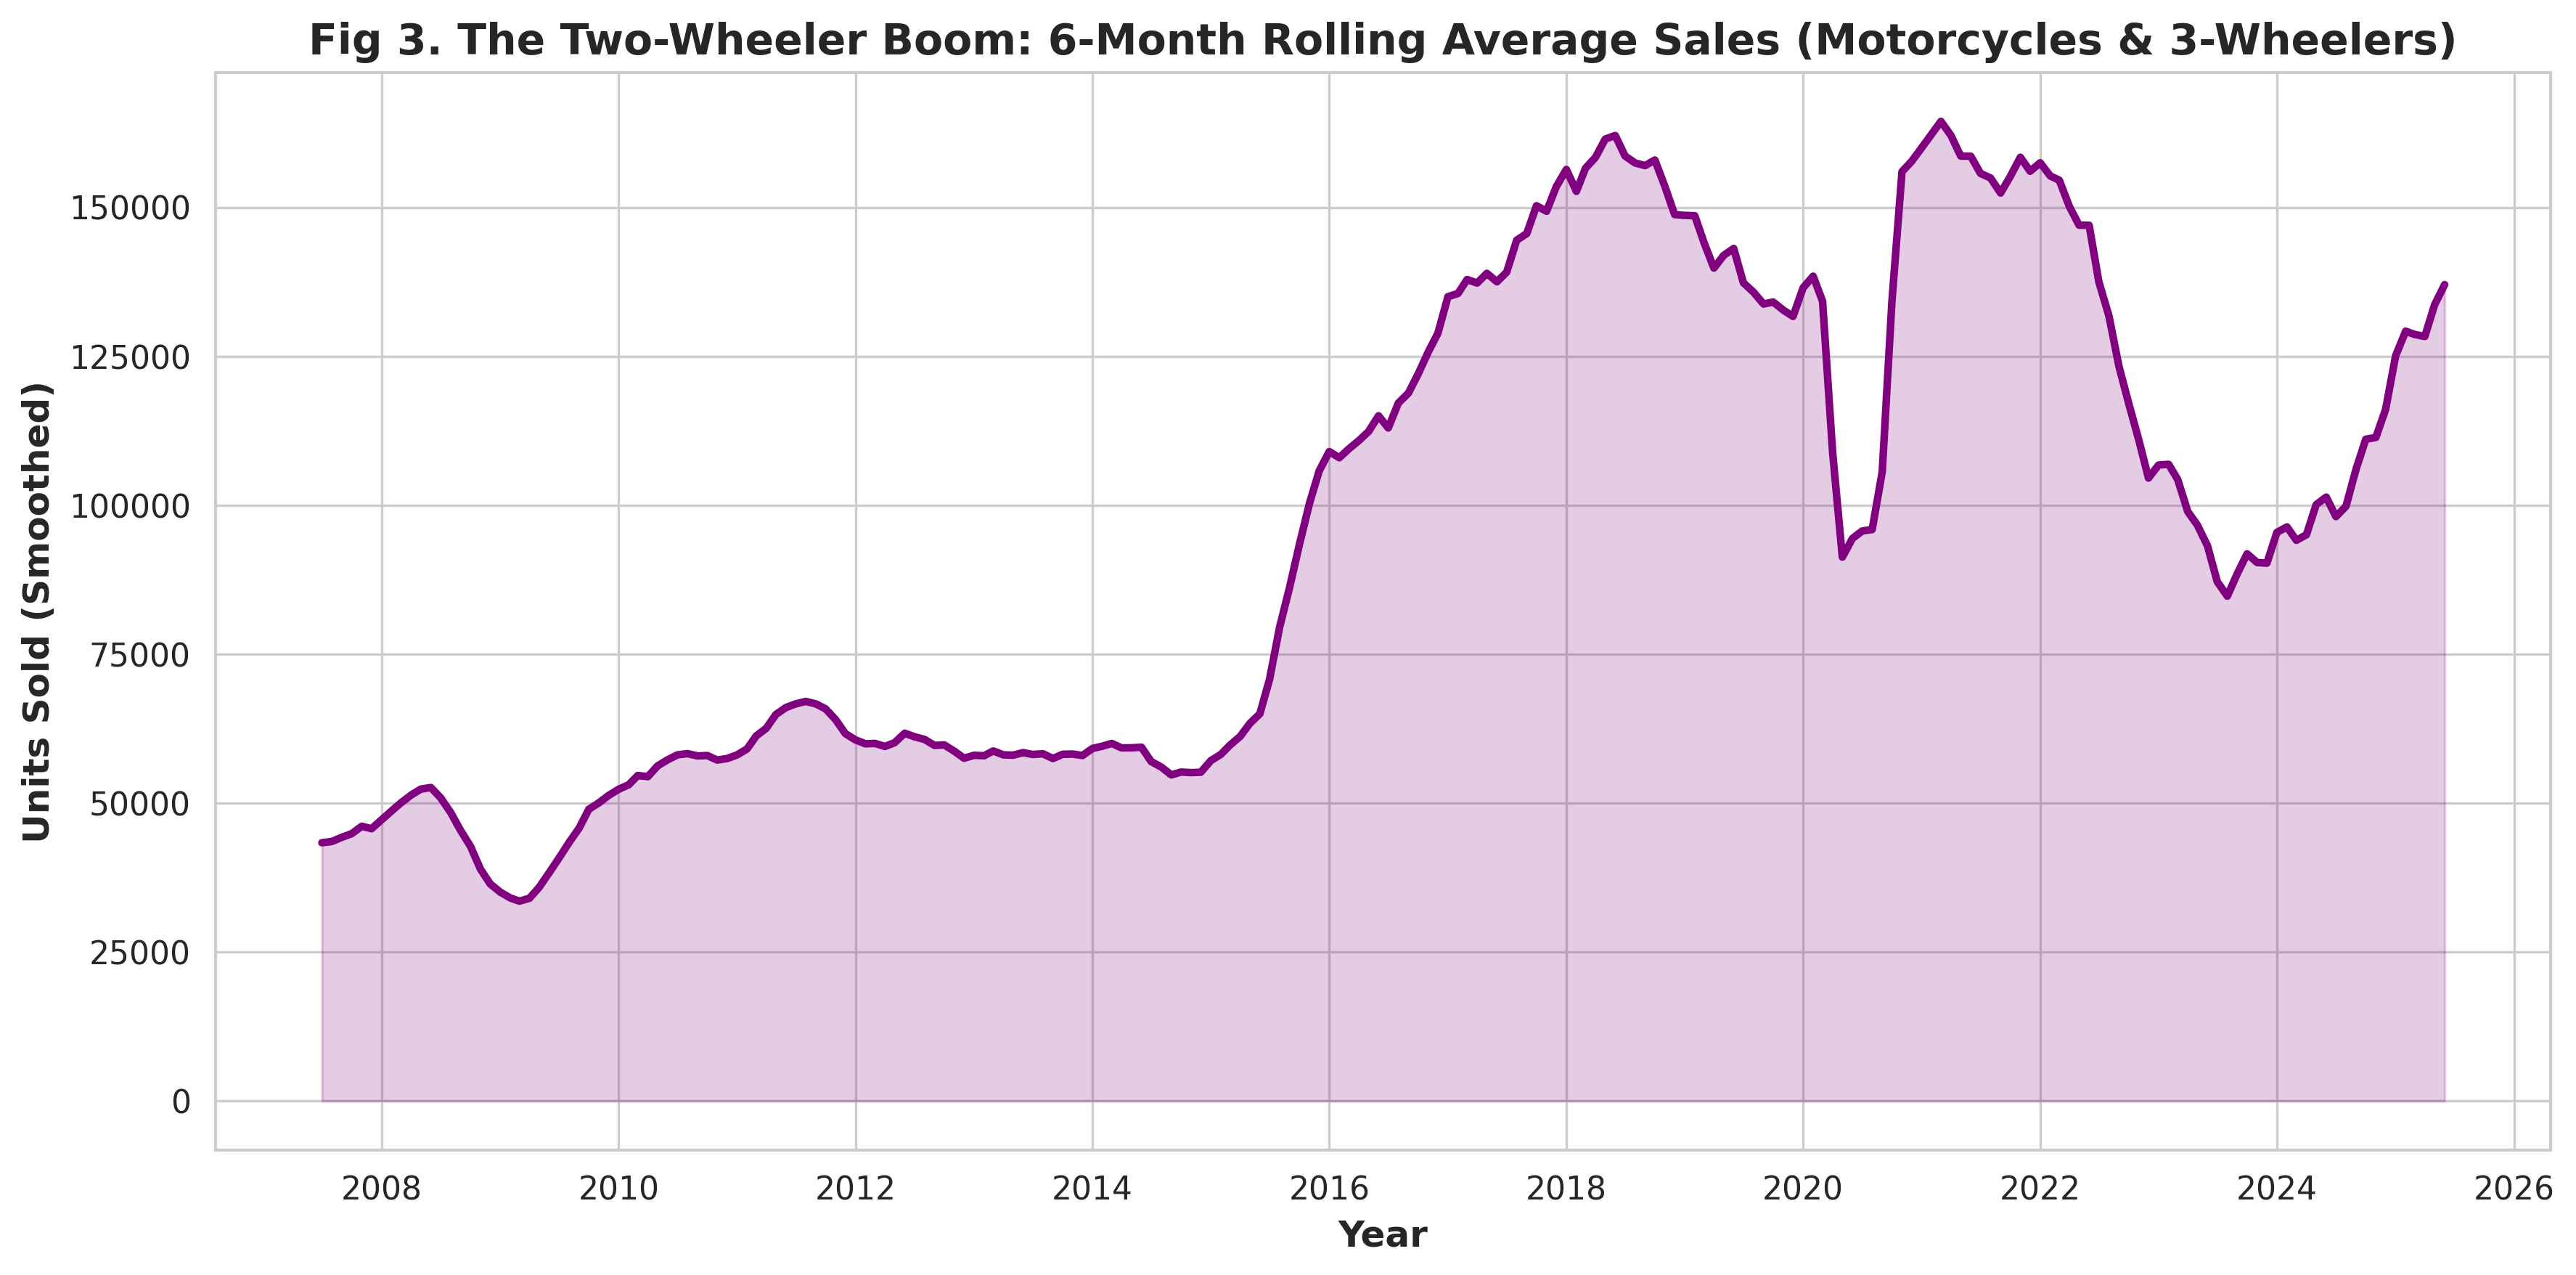


STATISTICAL SUMMARY FOR IEEE RESEARCH PAPER
Total Passenger Cars Sold (2007-2025): 3,038,858
Total Motorcycles & 3-Wheelers Sold (2007-2025): 20,787,967
Ratio of Bikes to Cars: 6.84 to 1

--- Market Share Shifts (Pre-2016 vs Post-2016) ---
Suzuki (Cars): 58.6% (Pre-2016) -> 53.4% (Post-2016)
Toyota: 28.7% (Pre-2016) -> 26.2% (Post-2016)
Honda (Cars): 11.7% (Pre-2016) -> 16.2% (Post-2016)
New Entrants (Crossovers/SUVs): 1.0% (Pre-2016) -> 4.2% (Post-2016)

--- Automotive Market Volatility ---
Peak Sales Year: 2021-22 (277,863 units)
Lowest Sales Year: 2008-09 (92,309 units)
Max Peak-to-Trough Drop: 66.8%


In [ ]:
# Notebook 2: Exploratory Data Analysis, BI & Statistics (02_eda_and_trends.ipynb)

from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
os.makedirs('/content/drive/MyDrive/DAV_Project/Final_Figures', exist_ok=True)


# 1. Setup & IEEE Formatting Standards
#drive.mount('/content/drive')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 300,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold'
})

# Load the dataset
file_path = '/content/drive/MyDrive/DAV_Project/01_pama_cleaned_long_format.csv'
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])

# Focus on 'Sales'
df_sales = df[df['Metric_Type'] == 'Sale'].copy()

# 2. Advanced Categorization Engine (Cars vs Motorcycles)
def categorize_automaker(brand):
    brand_upper = str(brand).strip().upper()

    # Isolate 2-Wheelers & 3-Wheelers
    if brand_upper in ['HONDA', 'SUZUKI', 'YAMAHA', 'ROAD PRINCE MOTORCYCLE', 'UNITED AUTO MOTORCYCLE'] or 'THREE' in brand_upper or 'QINGQI' in brand_upper:
        return 'Motorcycles & 3-Wheelers'

    # Categorize Passenger Vehicles
    elif 'SUZUKI' in brand_upper:
        return 'Suzuki (Cars)'
    elif 'TOYOTA' in brand_upper or 'INDUS' in brand_upper:
        return 'Toyota'
    elif 'HONDA' in brand_upper:
        return 'Honda (Cars)'
    elif any(ent in brand_upper for ent in ['KIA', 'HYUNDAI', 'BAIC', 'CHANGAN', 'HAVAL', 'SAZGAR', 'CHERY', 'PEUGEOT', 'MG']):
        return 'New Entrants (Crossovers/SUVs)'
    else:
        return 'Commercial/Tractors/Others'

df_sales['Market_Segment'] = df_sales['Brand_Model'].apply(categorize_automaker)

# Split datasets for scale differences
df_cars = df_sales[df_sales['Market_Segment'].isin(['Suzuki (Cars)', 'Toyota', 'Honda (Cars)', 'New Entrants (Crossovers/SUVs)'])]
df_bikes = df_sales[df_sales['Market_Segment'] == 'Motorcycles & 3-Wheelers']

# ==========================================
# Task A: Market Share Evolution (Passenger Cars)
# ==========================================
yearly_sales = df_cars.groupby(['Fiscal_Year', 'Market_Segment'])['Units'].sum().unstack(fill_value=0)
yearly_share = yearly_sales.div(yearly_sales.sum(axis=1), axis=0) * 100

fig1, ax1 = plt.subplots(figsize=(12, 6))
color_map = {'Suzuki (Cars)': '#1f77b4', 'Toyota': '#d62728', 'Honda (Cars)': '#2ca02c', 'New Entrants (Crossovers/SUVs)': '#ff7f0e'}
ordered_segments = ['Suzuki (Cars)', 'Toyota', 'Honda (Cars)', 'New Entrants (Crossovers/SUVs)']
plot_segments = [col for col in ordered_segments if col in yearly_share.columns]

ax1.stackplot(yearly_share.index, [yearly_share[col] for col in plot_segments], labels=plot_segments, colors=[color_map[col] for col in plot_segments], alpha=0.85)
ax1.set_title("Fig 1. Erosion of the 'Big 3' Monopoly: Passenger Car Market Share (2007-2025)")
ax1.set_ylabel("Market Share (%)")
ax1.set_xlabel("Fiscal Year")
plt.xticks(rotation=45, ha='right')
ax1.set_ylim(0, 100)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DAV_Project/02_Task_A_Market_Share.png', bbox_inches='tight')
plt.show()

# ==========================================
# Task B: Consumer Shifts (Rolling Avg - Cars)
# ==========================================
trend_data = df_cars.groupby(['Date', 'Market_Segment'])['Units'].sum().reset_index()
trend_pivot = trend_data.pivot(index='Date', columns='Market_Segment', values='Units').fillna(0)
trend_smoothed = trend_pivot.rolling(window=6, min_periods=1).mean()

fig2, ax2 = plt.subplots(figsize=(12, 6))
for col in plot_segments:
    ax2.plot(trend_smoothed.index, trend_smoothed[col], label=col, color=color_map[col], linewidth=2.5)

ax2.set_title("Fig 2. Macro Volatility & Policy Shocks: 6-Month Rolling Average Sales (Cars)")
ax2.set_ylabel("Units Sold (Smoothed)")
ax2.set_xlabel("Year")
adp_date = pd.to_datetime('2016-07-01')
ax2.axvline(adp_date, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
ax2.text(adp_date + pd.DateOffset(months=3), ax2.get_ylim()[1]*0.85, 'Auto Policy 2016-21\n(New Entrants Entry)', color='black', fontsize=10)
ax2.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DAV_Project/02_Task_B_Car_Trends.png', bbox_inches='tight')
plt.show()

# ==========================================
# Task C: The Motorcycle Market Boom
# ==========================================
bike_trend = df_bikes.groupby('Date')['Units'].sum().reset_index()
bike_smoothed = bike_trend.set_index('Date')['Units'].rolling(window=6, min_periods=1).mean()

fig3, ax3 = plt.subplots(figsize=(12, 6))
ax3.plot(bike_smoothed.index, bike_smoothed.values, color='purple', linewidth=2.5)
ax3.set_title("Fig 3. The Two-Wheeler Boom: 6-Month Rolling Average Sales (Motorcycles & 3-Wheelers)")
ax3.set_ylabel("Units Sold (Smoothed)")
ax3.set_xlabel("Year")
ax3.fill_between(bike_smoothed.index, bike_smoothed.values, alpha=0.2, color='purple')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DAV_Project/02_Task_C_Motorcycle_Trends.png', bbox_inches='tight')
plt.show()

# ==========================================
# DESCRIPTIVE STATISTICS GENERATOR (FOR RESEARCH PAPER)
# ==========================================
print("\n" + "="*60)
print("STATISTICAL SUMMARY FOR IEEE RESEARCH PAPER")
print("="*60)

# Total Volumes
total_cars = df_cars['Units'].sum()
total_bikes = df_bikes['Units'].sum()
print(f"Total Passenger Cars Sold (2007-2025): {total_cars:,.0f}")
print(f"Total Motorcycles & 3-Wheelers Sold (2007-2025): {total_bikes:,.0f}")
print(f"Ratio of Bikes to Cars: {(total_bikes/total_cars):.2f} to 1\n")

# Market Share Pre vs Post ADP Policy (2016)
pre_2016 = df_cars[df_cars['Date'] < '2016-07-01']
post_2016 = df_cars[df_cars['Date'] >= '2016-07-01']

pre_shares = (pre_2016.groupby('Market_Segment')['Units'].sum() / pre_2016['Units'].sum() * 100)
post_shares = (post_2016.groupby('Market_Segment')['Units'].sum() / post_2016['Units'].sum() * 100)

print("--- Market Share Shifts (Pre-2016 vs Post-2016) ---")
for brand in plot_segments:
    pre_val = pre_shares.get(brand, 0)
    post_val = post_shares.get(brand, 0)
    print(f"{brand}: {pre_val:.1f}% (Pre-2016) -> {post_val:.1f}% (Post-2016)")

# Volatility (Variance)
peak_car_year = yearly_sales.sum(axis=1).idxmax()
peak_car_vol = yearly_sales.sum(axis=1).max()
low_car_year = yearly_sales.sum(axis=1).idxmin()
low_car_vol = yearly_sales.sum(axis=1).min()

print("\n--- Automotive Market Volatility ---")
print(f"Peak Sales Year: {peak_car_year} ({peak_car_vol:,.0f} units)")
print(f"Lowest Sales Year: {low_car_year} ({low_car_vol:,.0f} units)")
print(f"Max Peak-to-Trough Drop: {((peak_car_vol - low_car_vol) / peak_car_vol * 100):.1f}%")
print("="*60)